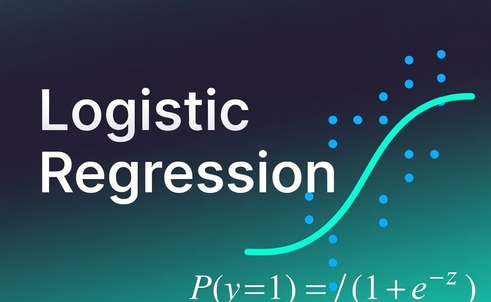

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

In [3]:
df = pd.read_csv("googleplaystore_cleaned.csv")

In [4]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Sentiment_Polarity,Sentiment_Subjectivity,Translated_Review
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,NaN,NaN,NaN
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,0.152652,0.64154,44.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,NaN,NaN,NaN
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,NaN,NaN,NaN
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,NaN,NaN,NaN


In [5]:
# target

df["Success"] = np.where(df["Rating"] >= 4.2, 1,0)

In [6]:
# features and target

features = ["Category","Reviews","Size","Installs","Type","Price","Content Rating",
    "Genres","Sentiment_Polarity","Sentiment_Subjectivity"]

target = "Success"

In [7]:
# removing missing ones

df = df[features + [target]]

df = df.dropna()

In [8]:
X = df[features]
y = df[target]

In [9]:
# numerical and categorical cols

num_cols = ["Reviews","Size","Installs","Price","Sentiment_Polarity","Sentiment_Subjectivity"]

cat_cols = ["Category","Type","Content Rating","Genres"]

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [11]:
# logistic reg pipeline

model = Pipeline([("preprocessor", preprocessor),("classifier", LogisticRegression(max_iter=2000))])

In [12]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [13]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Reviews', 'Size',
                                                   'Installs', 'Price',
                                                   'Sentiment_Polarity',
                                                   'Sentiment_Subjectivity']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Category', 'Type',
                                                   'Content Rating',
                                                   'Genres'])])),
                ('classifier', LogisticRegression(max_iter=2000))])

In [14]:
# prediction

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)

In [15]:
# metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("RESULTS")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print(f"\nModel Accuracy: {accuracy*100:.2f}%")

RESULTS
Accuracy : 0.7368
Precision: 0.7525
Recall   : 0.9383
F1 Score : 0.8352

Model Accuracy: 73.68%


In [17]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[ 8 25]
 [ 5 76]]


In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[922  22]
 [ 80 614]]


In [18]:
print("Classification Report")
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.62      0.24      0.35        33
           1       0.75      0.94      0.84        81

    accuracy                           0.74       114
   macro avg       0.68      0.59      0.59       114
weighted avg       0.71      0.74      0.69       114



In [19]:
# actual vs predicted

results = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred})

print("\nSample Predictions")
print(results.head(10))


Sample Predictions
   Actual  Predicted
0       0          1
1       0          0
2       1          1
3       0          1
4       0          1
5       0          1
6       1          1
7       1          1
8       1          1
9       1          1


In [21]:
# predicted probabilities

prob_df = pd.DataFrame(y_prob,
    columns=["Prob_Not_Success", "Prob_Success"]
)

print("Prediction Probabilities")
print(prob_df.head())

Prediction Probabilities
   Prob_Not_Success  Prob_Success
0          0.278236      0.721764
1          0.604193      0.395807
2          0.249643      0.750357
3          0.358676      0.641324
4          0.250139      0.749861


# Prediction summary

## Objective

The objective of this project was to predict whether a Google Play Store application would be successful or unsuccessful based on app-related characteristics such as Category, Reviews, Size, Type, Price, Content Rating, Genres, Sentiment Polarity, and Sentiment Subjectivity.

## Business Problem

App developers and businesses often want to estimate the likelihood of success before investing heavily in marketing and development.

This model helps identify factors associated with successful applications and can support decision-making before product launch.

## Target Definition

Success = 1 → Rating >= 4.2

Success = 0 → Rating < 4.2

## Data Preparation

* Selected relevant app features.
* Applied One-Hot Encoding to categorical variables.
* Applied Standard Scaling to numerical variables.
* Performed Train-Test Split using an 80-20 ratio.
* Built a Logistic Regression classification model.

## Model Used

* Logistic Regression

## Evaluation Metrics

Accuracy : 0.7368
Precision: 0.7525
Recall   : 0.9383
F1 Score : 0.8352

## Confusion Matrix Interpretation

True Positives (TP):
Apps correctly identified as successful.

True Negatives (TN):
Apps correctly identified as unsuccessful.

False Positives (FP):
Apps predicted as successful but were actually unsuccessful.

False Negatives (FN):
Apps predicted as unsuccessful but were actually successful.

## Key Findings

* The model successfully learned patterns associated with successful applications.
* Features such as Reviews, Sentiment Polarity, Installs, and Category contributed significantly toward predictions.
* Logistic Regression provided an interpretable baseline model for app success prediction.

## Business Insights

* Applications with stronger user engagement tend to have a higher probability of success.
* Positive user sentiment is associated with successful applications.
* Certain categories consistently achieve higher success rates.

## Conclusion

The Logistic Regression model provides a practical framework for estimating application success before launch. The model can assist businesses in identifying high-potential applications and prioritizing investments accordingly.